<a href="https://colab.research.google.com/github/shehanmakani/gold-price-prediction/blob/main/ML_FinalProject_GoldPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from xgboost import XGBRegressor
print("XGBoost imported successfully")


XGBoost imported successfully


Data loaded successfully
Shape: (3104, 7)
        Date  Price   Open   High    Low  Volume  Chg%
0 2014-01-01  29542  29435  29598  29340    2930  0.25
1 2014-01-02  29975  29678  30050  29678    3140  1.47
2 2014-01-03  29727  30031  30125  29539    3050 -0.83
3 2014-01-04  29279  29279  29279  29279       0 -1.51
4 2014-01-06  29119  29300  29395  29051   24380 -0.55


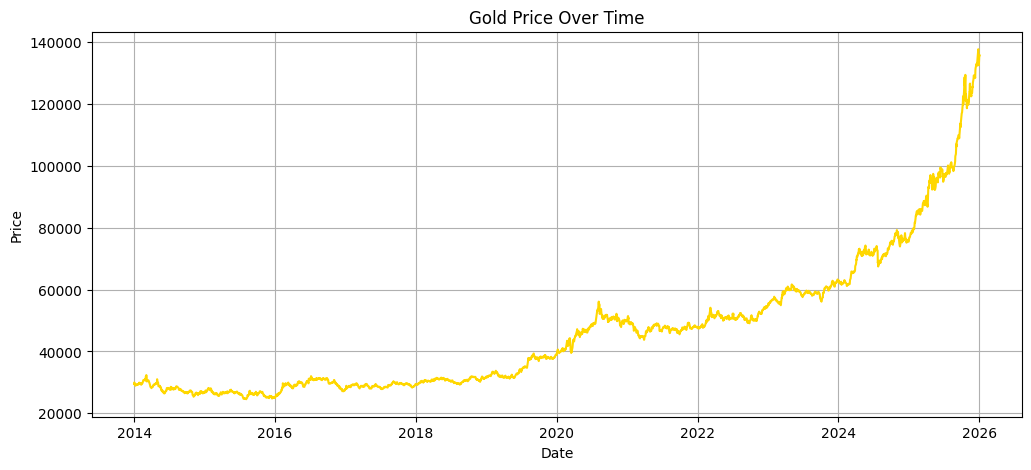

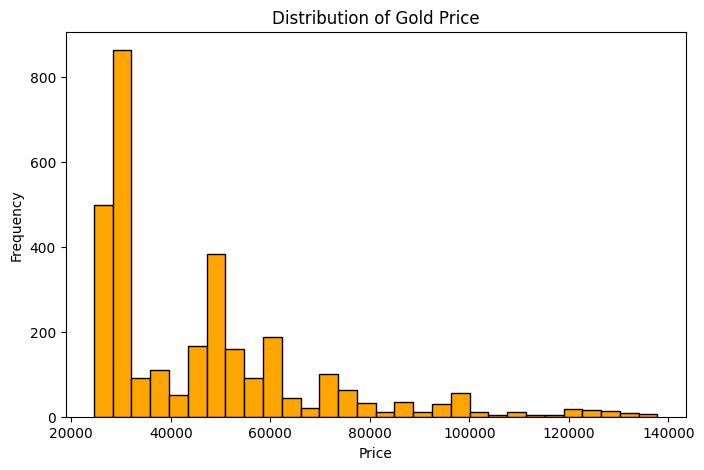

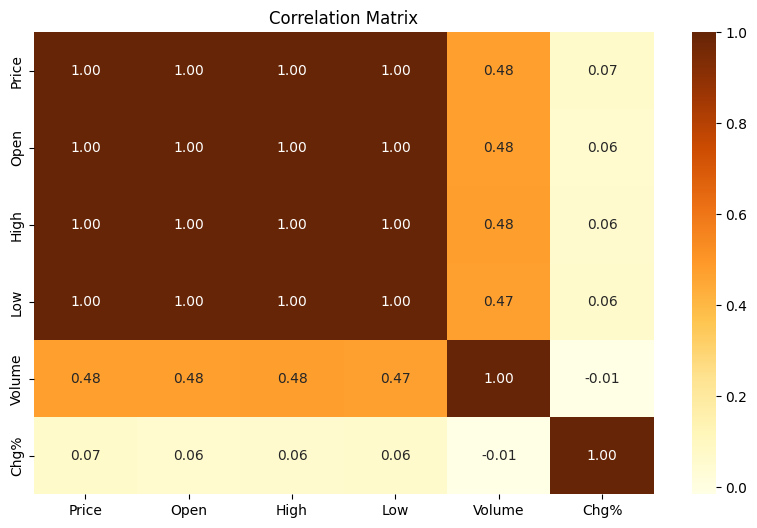

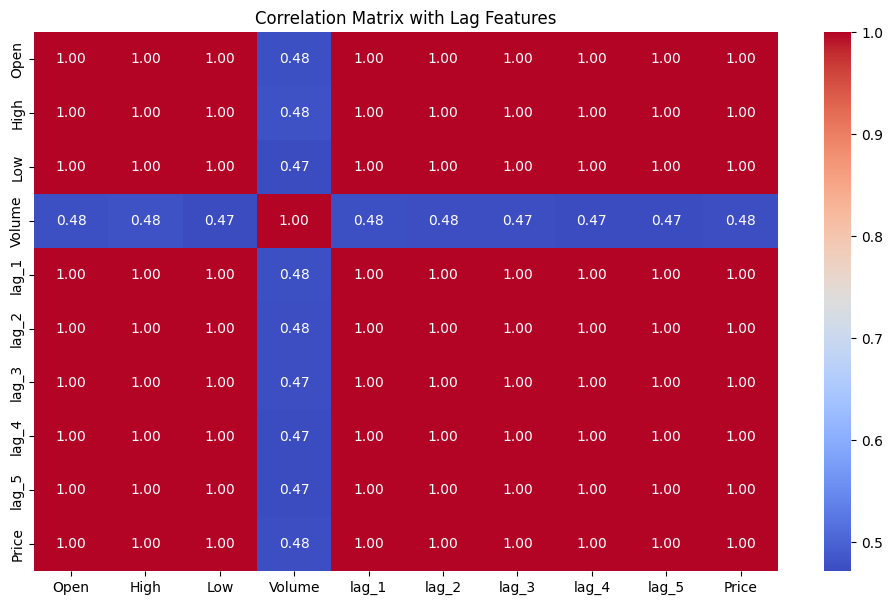

Training set: (2479, 9)
Testing set: (620, 9)
Training Ridge Regression...
Training Random Forest...
Training XGBoost...
Training Support Vector Regression...

MODEL PERFORMANCE ON TEST SET
                       Model         MAE        RMSE  MAPE (%)  \
0           Ridge Regression    196.4283    296.5583    0.2291   
1              Random Forest  21001.1510  29191.7766   21.5071   
2                    XGBoost  21523.4844  29614.3263   22.1544   
3  Support Vector Regression  42748.2118  47916.3154   49.0447   

   Directional Accuracy (%)  R2 Score  
0                   82.0679    0.9998  
1                   31.5024   -1.0085  
2                    9.5315   -1.0671  
3                   36.5105   -4.4116  

CROSS-VALIDATION RESULTS (Mean ± Std Across Folds)
                       Model                      MAE  \
0           Ridge Regression       119.3212 ± 54.7270   
1              Random Forest    7024.9526 ± 8685.4902   
2                    XGBoost    7347.0668 ± 8877.4139   

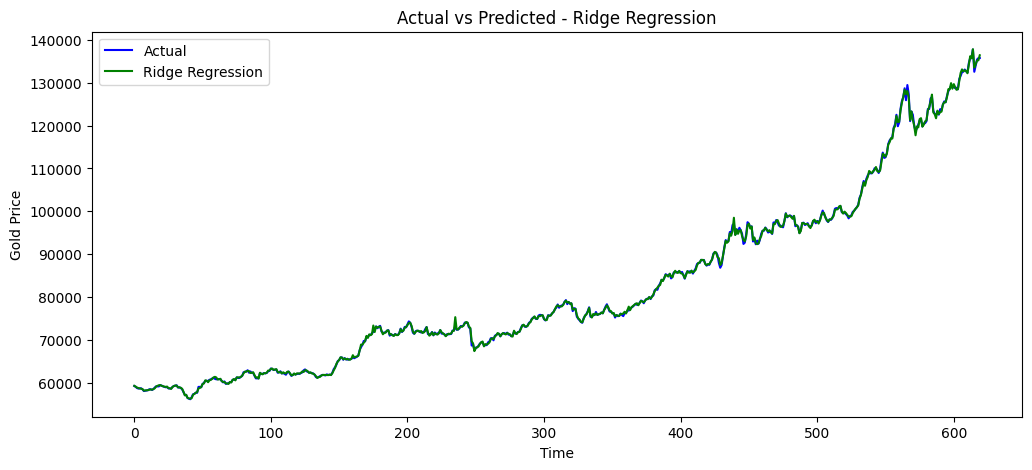

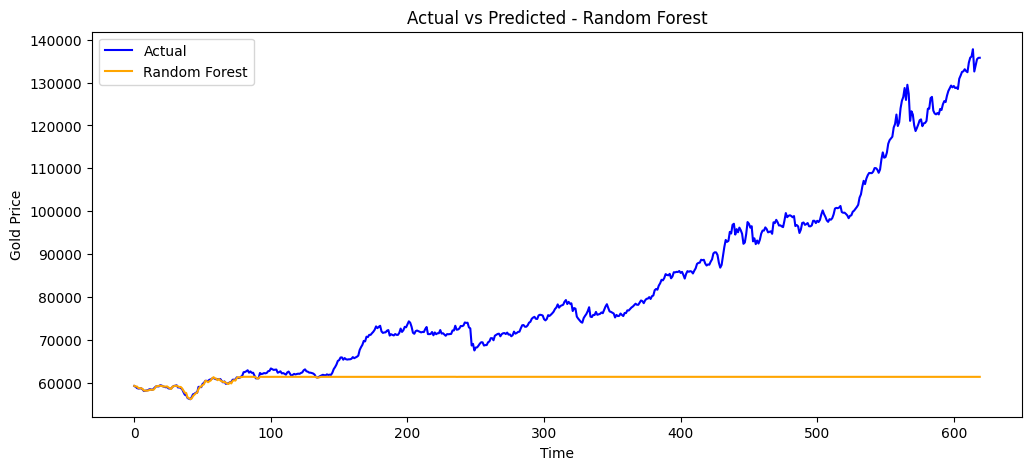

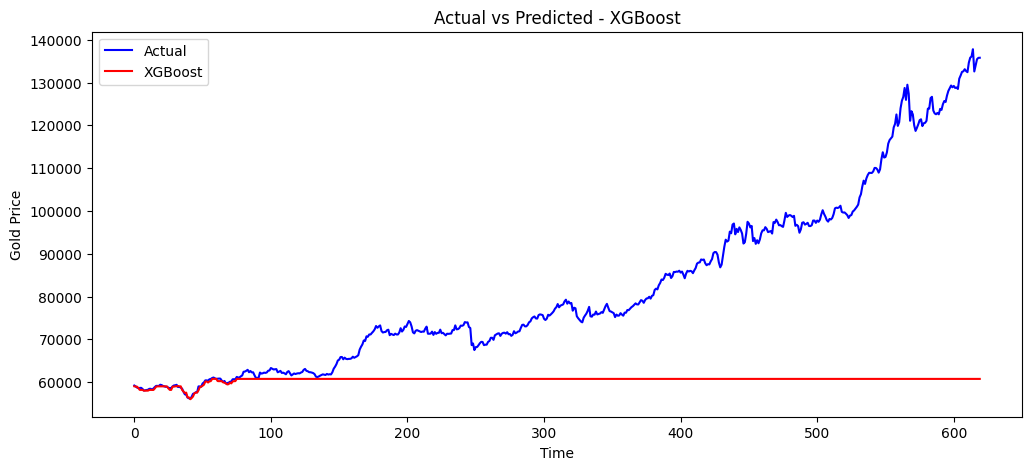

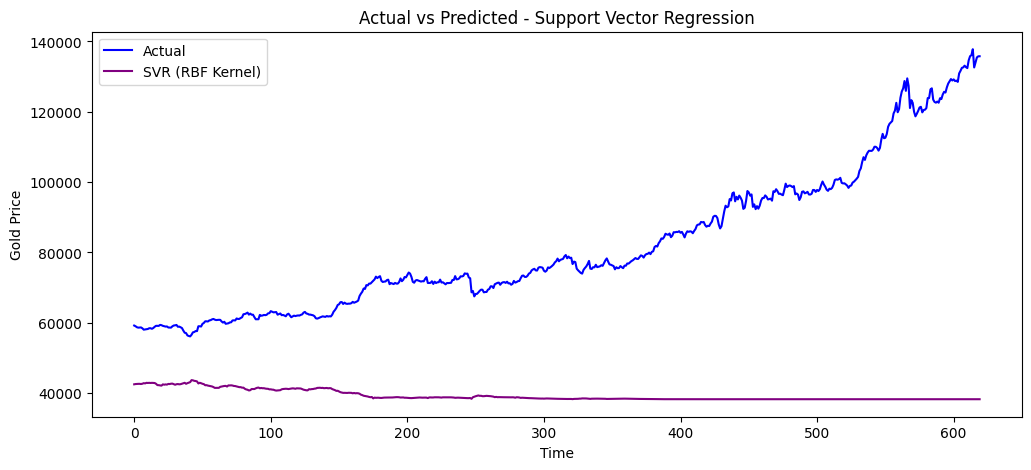

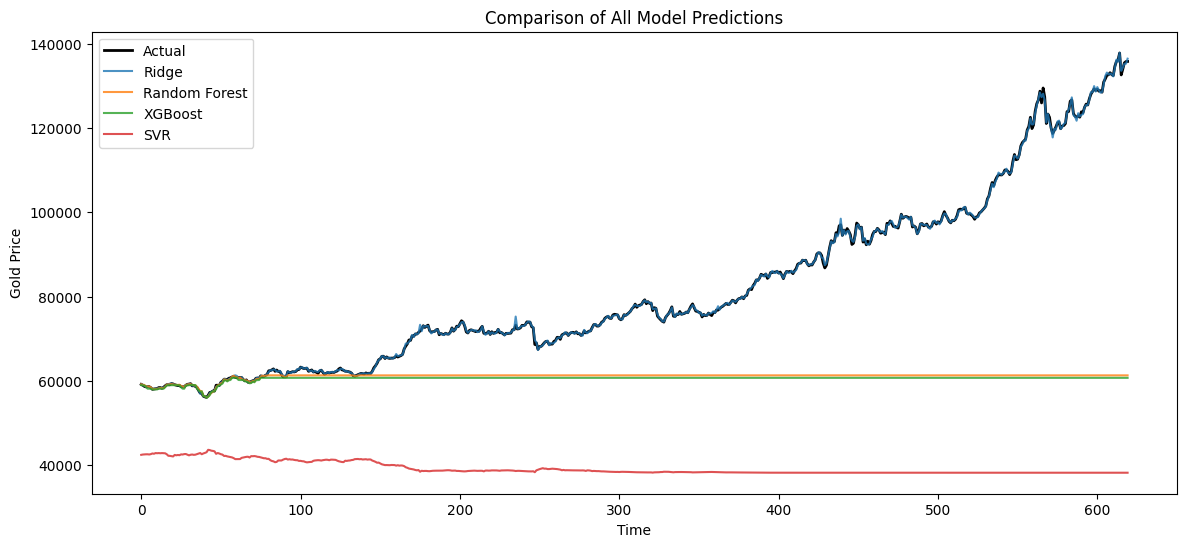

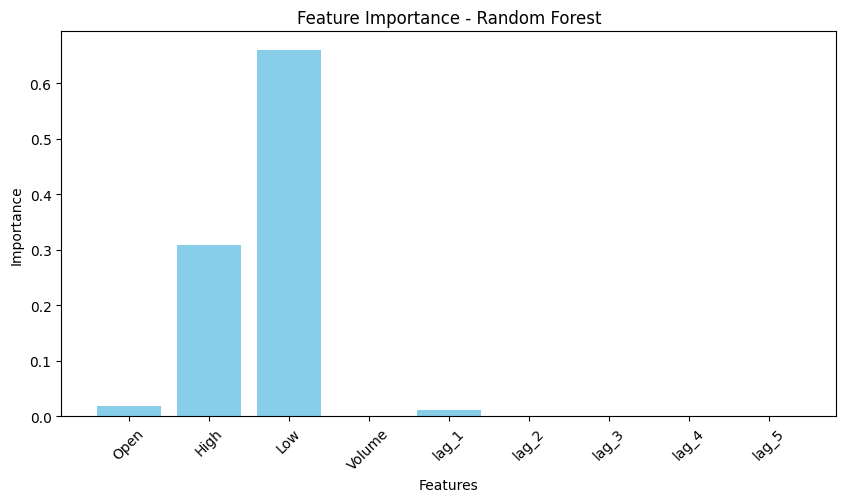

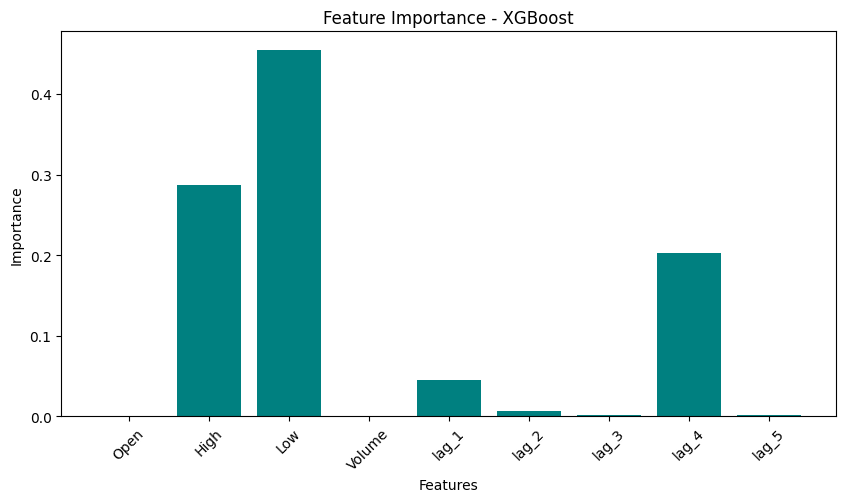

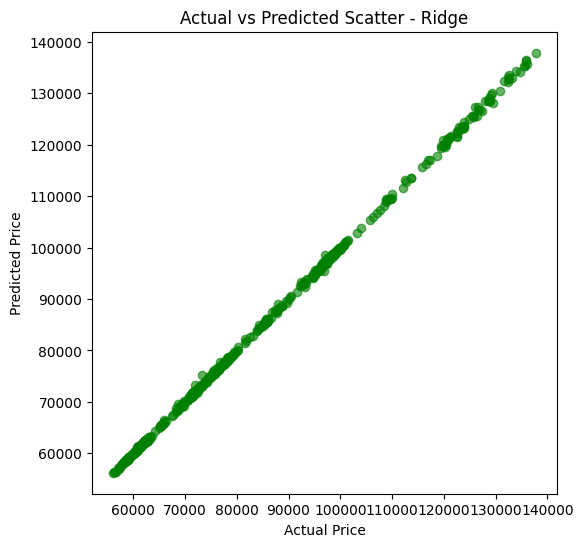

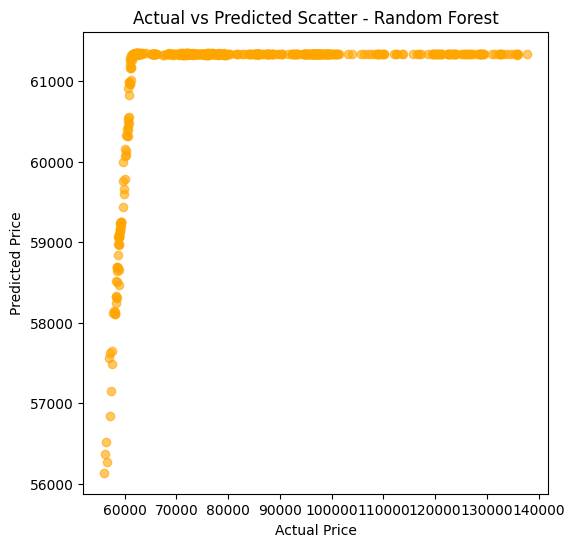

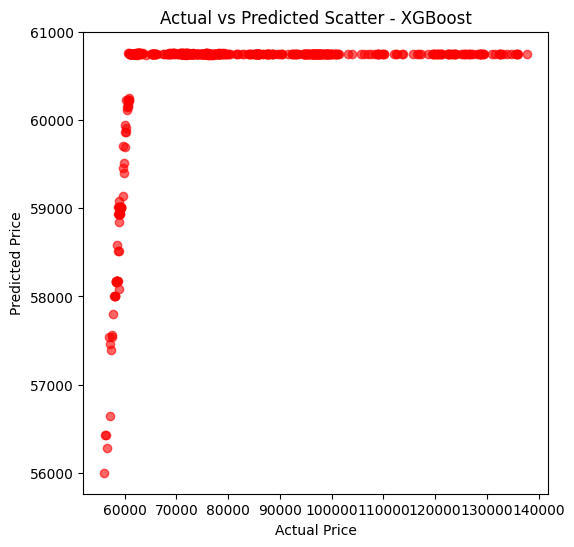

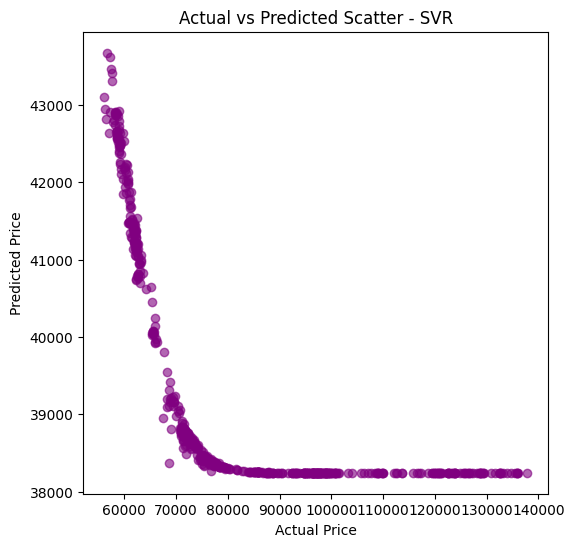

In [ ]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


# LOAD DATA

file_path = "/Users/sathwika/Desktop/Gold Price.csv"
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)


# CLEAN DATA

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("K", "000", regex=False)
        .str.replace("M", "000000", regex=False),
        errors="coerce"
    )

for col in ["Price", "Open", "High", "Low", "Volume"]:
    df[col] = clean_numeric(df[col])

if "Chg%" in df.columns:
    df["Chg%"] = clean_numeric(df["Chg%"])

df = df.dropna(subset=["Price", "Open", "High", "Low", "Volume"]).reset_index(drop=True)

print("Data loaded successfully")
print("Shape:", df.shape)
print(df.head())


# EDA / VISUALIZATION

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"], color="gold")
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=30, color="orange", edgecolor="black")
plt.title("Distribution of Gold Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


#  FEATURE ENGINEERING

for i in range(1, 6):
    df[f"lag_{i}"] = df["Price"].shift(i)

df = df.dropna().reset_index(drop=True)

feature_cols = [
    "Open", "High", "Low", "Volume",
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_5"
]

X = df[feature_cols]
y = df["Price"]

plt.figure(figsize=(12, 7))
sns.heatmap(df[feature_cols + ["Price"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix with Lag Features")
plt.show()


# TRAIN-TEST SPLIT

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


# SCALING FOR SVR

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# METRIC FUNCTIONS

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    actual_direction = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))

    return np.mean(actual_direction == predicted_direction) * 100

def evaluate(y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mape = mean_absolute_percentage_error(y_true, pred)
    da = directional_accuracy(y_true, pred)
    r2 = r2_score(y_true, pred)
    return mae, rmse, mape, da, r2


# BUILD MODELS

ridge = Ridge(alpha=1.0)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

svr = SVR(kernel="rbf", C=10)


# TRAIN MODELS

print("Training Ridge Regression...")
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("Training Random Forest...")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Training XGBoost...")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("Training Support Vector Regression...")
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)


# TEST SET EVALUATION

results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "XGBoost",
        "Support Vector Regression"
    ],
    "MAE": [
        evaluate(y_test, ridge_pred)[0],
        evaluate(y_test, rf_pred)[0],
        evaluate(y_test, xgb_pred)[0],
        evaluate(y_test, svr_pred)[0]
    ],
    "RMSE": [
        evaluate(y_test, ridge_pred)[1],
        evaluate(y_test, rf_pred)[1],
        evaluate(y_test, xgb_pred)[1],
        evaluate(y_test, svr_pred)[1]
    ],
    "MAPE (%)": [
        evaluate(y_test, ridge_pred)[2],
        evaluate(y_test, rf_pred)[2],
        evaluate(y_test, xgb_pred)[2],
        evaluate(y_test, svr_pred)[2]
    ],
    "Directional Accuracy (%)": [
        evaluate(y_test, ridge_pred)[3],
        evaluate(y_test, rf_pred)[3],
        evaluate(y_test, xgb_pred)[3],
        evaluate(y_test, svr_pred)[3]
    ],
    "R2 Score": [
        evaluate(y_test, ridge_pred)[4],
        evaluate(y_test, rf_pred)[4],
        evaluate(y_test, xgb_pred)[4],
        evaluate(y_test, svr_pred)[4]
    ]
})

print("\nMODEL PERFORMANCE ON TEST SET")
print(results.round(4))


# TIME SERIES CROSS-VALIDATION

tscv = TimeSeriesSplit(n_splits=5)

def cross_validate_model(model_name, model, X, y, scale=False):
    mae_scores = []
    rmse_scores = []
    mape_scores = []
    da_scores = []
    r2_scores = []

    for train_idx, test_idx in tscv.split(X):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        if scale:
            scaler_cv = StandardScaler()
            X_train_cv = scaler_cv.fit_transform(X_train_cv)
            X_test_cv = scaler_cv.transform(X_test_cv)

        model.fit(X_train_cv, y_train_cv)
        pred_cv = model.predict(X_test_cv)

        mae, rmse, mape, da, r2 = evaluate(y_test_cv, pred_cv)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)
        da_scores.append(da)
        r2_scores.append(r2)

    return {
        "Model": model_name,
        "MAE": f"{np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}",
        "RMSE": f"{np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}",
        "MAPE (%)": f"{np.mean(mape_scores):.4f} ± {np.std(mape_scores):.4f}",
        "Directional Accuracy (%)": f"{np.mean(da_scores):.4f} ± {np.std(da_scores):.4f}",
        "R2 Score": f"{np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}"
    }

cv_results = []
cv_results.append(cross_validate_model("Ridge Regression", Ridge(alpha=1.0), X, y, scale=False))
cv_results.append(cross_validate_model("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42), X, y, scale=False))
cv_results.append(cross_validate_model("XGBoost", XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42), X, y, scale=False))
cv_results.append(cross_validate_model("Support Vector Regression", SVR(kernel="rbf", C=10), X, y, scale=True))

cv_results_df = pd.DataFrame(cv_results)

print("\nCROSS-VALIDATION RESULTS (Mean ± Std Across Folds)")
print(cv_results_df)


# ACTUAL VS PREDICTED PLOTS

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(ridge_pred, label="Ridge Regression", color="green")
plt.title("Actual vs Predicted - Ridge Regression")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(rf_pred, label="Random Forest", color="orange")
plt.title("Actual vs Predicted - Random Forest")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(xgb_pred, label="XGBoost", color="red")
plt.title("Actual vs Predicted - XGBoost")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(svr_pred, label="SVR (RBF Kernel)", color="purple")
plt.title("Actual vs Predicted - Support Vector Regression")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()


# COMBINED COMPARISON PLOT

plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label="Actual", color="black", linewidth=2)
plt.plot(ridge_pred, label="Ridge", alpha=0.8)
plt.plot(rf_pred, label="Random Forest", alpha=0.8)
plt.plot(xgb_pred, label="XGBoost", alpha=0.8)
plt.plot(svr_pred, label="SVR", alpha=0.8)
plt.title("Comparison of All Model Predictions")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()


# FEATURE IMPORTANCE

plt.figure(figsize=(10, 5))
plt.bar(feature_cols, rf.feature_importances_, color="skyblue")
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(feature_cols, xgb.feature_importances_, color="teal")
plt.xticks(rotation=45)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


# SCATTER PLOTS

plt.figure(figsize=(6, 6))
plt.scatter(y_test, ridge_pred, alpha=0.6, color="green")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter - Ridge")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, color="orange")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter - Random Forest")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_pred, alpha=0.6, color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter - XGBoost")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, svr_pred, alpha=0.6, color="purple")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter - SVR")
plt.show()
